# Market Risk Lab – Zadanie Domowe 2
## Value at Risk: metody historyczna i parametryczna

**Autor:** Oleksandra Krykun – oleksandrakrykun2@gmail.com  
**Data:** 21 kwietnia 2026  
**Kurs:** Market Risk Lab  

---

## 1. Import bibliotek i pobranie danych

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

TICKERS = ['GS', 'C', 'AIG', 'BAC', 'MS']
NAMES   = {'GS': 'Goldman Sachs', 'C': 'Citigroup',
           'AIG': 'AIG', 'BAC': 'Bank of America', 'MS': 'Morgan Stanley'}
START   = '2006-08-01'
END     = '2008-07-31'
COLORS  = ['#2196F3', '#E91E63', '#FF5722', '#4CAF50', '#9C27B0']

In [2]:
data = yf.download(TICKERS, start = START, end = END, auto_adjust=False)["Adj Close"]
data = data[TICKERS]
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GS,C,AIG,BAC,MS
Date,,,,,
2006-08-01,110.278687,315.891113,727.275818,34.087532,35.724304
2006-08-02,109.287117,317.258514,726.432129,34.371990,35.881428
2006-08-03,110.891075,318.837250,722.695984,34.378605,36.732006
2006-08-04,111.540009,319.034546,723.901428,34.610138,36.672409
2006-08-07,111.292068,317.258514,720.768066,34.504295,36.374432


## 2. Logarytmiczne stopy zwrotu

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [3]:
log_ret = np.log(data / data.shift(1)).dropna()
log_ret.head()

Ticker,GS,C,AIG,BAC,MS
Date,,,,,
2006-08-02,-0.009032,0.004319,-0.001161,0.008310,0.004389
2006-08-03,0.014570,0.004964,-0.005156,0.000192,0.023429
2006-08-04,0.005835,0.000619,0.001667,0.006712,-0.001624
2006-08-07,-0.002225,-0.005582,-0.004338,-0.003063,-0.008159
2006-08-08,-0.007892,0.001657,-0.002176,-0.001919,-0.012892


## 3. Definicja portfeli

- **Portfel A – równe wagi (1/N):** każda z 5 spółek ma wagę 20%.
- **Portfel B – losowe wagi:** wagi wylosowane z rozkładu Dirichleta (suma = 1), z ustalonym ziarnem dla powtarzalności wyników.

Stopę zwrotu portfela obliczamy jako logarytm ilorazu wartości portfela w kolejnych dniach:

$$r_t^P = \ln\left(\frac{\sum_i w_i \cdot P_{t,i}}{\sum_i w_i \cdot P_{t-1,i}}\right)$$

gdzie $w_i$ to waga spółki $i$ w portfelu, a $P_{t,i}$ to cena akcji spółki $i$ w dniu $t$.

In [4]:
np.random.seed(123) # dla powtarzalności wyników

w_A = np.array([1/5] * 5)
w_B = np.random.dirichlet(np.ones(5))

port_value_A = (data * w_A).sum(axis=1)
port_value_B = (data * w_B).sum(axis=1)

port_ret_A = np.log(port_value_A / port_value_A.shift(1)).dropna()
port_ret_B = np.log(port_value_B / port_value_B.shift(1)).dropna()

print('Wagi portfeli:')
print(f'{"Ticker":<8}{"Portfel A (równe)":<22}{"Portfel B (losowe)"}')
print('-' * 48)
for t, wa, wb in zip(TICKERS, w_A, w_B):
    print(f'{t:<8}{wa*100:>10.1f}%{" ":>10}{wb*100:>10.2f}%')
print(f'{"SUMA":<8}{sum(w_A)*100:>10.1f}%{" ":>10}{sum(w_B)*100:>10.2f}%')
print(f'\nŁączna liczba obserwacji stóp zwrotu: {len(port_ret_A)}')
print(f'Zakres dat: {port_ret_A.index[0].date()} – {port_ret_A.index[-1].date()}')

Wagi portfeli:
Ticker  Portfel A (równe)     Portfel B (losowe)
------------------------------------------------
GS            20.0%               30.89%
C             20.0%                8.73%
AIG           20.0%                6.67%
BAC           20.0%               20.77%
MS            20.0%               32.94%
SUMA         100.0%              100.00%

Łączna liczba obserwacji stóp zwrotu: 502
Zakres dat: 2006-08-02 – 2008-07-30


## 4. Okno 250 dni roboczych

VaR wyznaczamy z **ostatnich 250 dni roboczych** – standardowe okno wymagane przez Basel II/III.

Okno 250 dni: 2007-08-03 – 2008-07-30
Liczba obserwacji: 250


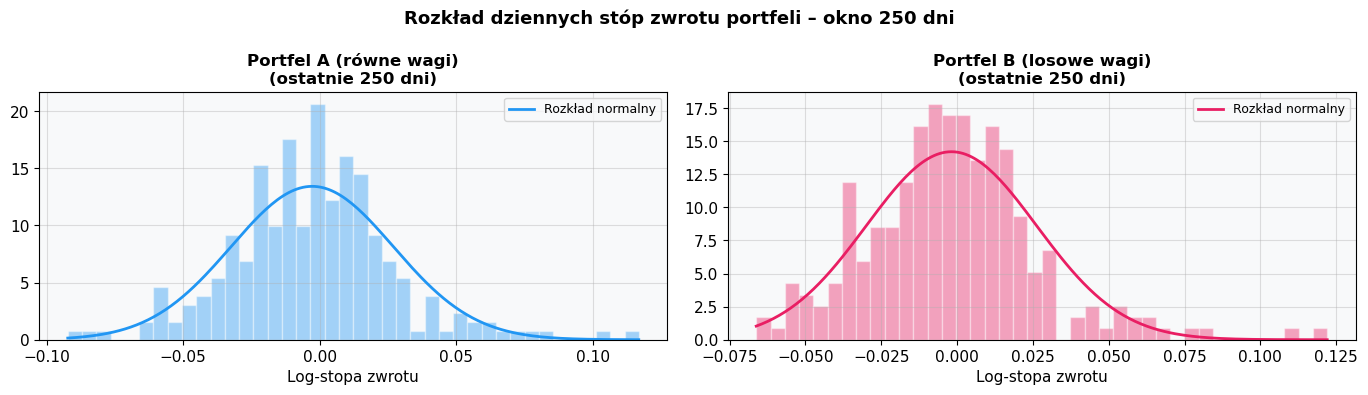

In [5]:
WINDOW = 250
ret_A_250 = port_ret_A.iloc[-WINDOW:]
ret_B_250 = port_ret_B.iloc[-WINDOW:]

print(f'Okno 250 dni: {ret_A_250.index[0].date()} – {ret_A_250.index[-1].date()}')
print(f'Liczba obserwacji: {len(ret_A_250)}')

# Przegląd rozkładu stóp zwrotu portfeli
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['Portfel A (równe wagi)', 'Portfel B (losowe wagi)'],
                                  ['#2196F3', '#E91E63']):
    ax.hist(ret, bins=40, color=color, alpha=0.4, edgecolor='white', density=True)
    x = np.linspace(ret.min(), ret.max(), 200)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=color, lw=2, label='Rozkład normalny')
    ax.set_title(f'{label}\n(ostatnie 250 dni)', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Rozkład dziennych stóp zwrotu portfeli – okno 250 dni', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('portfele_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Historyczny VaR (metoda symulacji historycznej)

**Idea:** VaR historyczny to empiryczny kwantyl rozkładu stóp zwrotu portfela z okna historycznego.  
Nie zakładamy żadnego rozkładu parametrycznego – używamy bezpośrednio zaobserwowanych zmian wartości.

$$\text{VaR}_{\alpha}^{\text{hist}} = -Q_{1-\alpha}(r_1, r_2, \ldots, r_{250})$$

gdzie $Q_{1-\alpha}$ oznacza kwantyl rzędu $(1-\alpha)$ empirycznego rozkładu stóp zwrotu.  

Dla poziomu ufności 95%: szukamy 5. percentyla (5% najgorszych wyników), tj. 12–13 najgorszy wynik z 250.  
Dla poziomu ufności 99%: szukamy 1. percentyla, tj. 2–3 najgorszy wynik z 250.

Historyczny VaR (jako % wartości portfela):
Portfel          VaR 95%     VaR 99%
------------------------------------
Portfel A         5.059%       7.092%
Portfel B         4.632%       5.590%


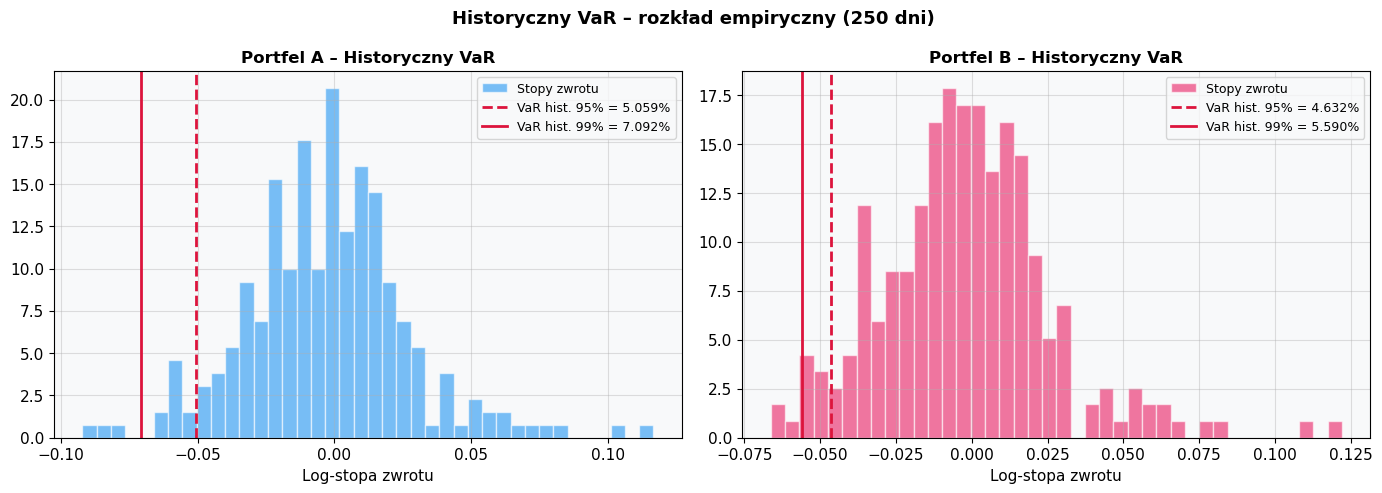

In [6]:
CONF_LEVELS = [0.95, 0.99]

var_hist = {}
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    var_hist[label] = {}
    for cl in CONF_LEVELS:
        var_hist[label][cl] = -np.quantile(ret, 1 - cl)

print('Historyczny VaR (jako % wartości portfela):')
print(f'{"Portfel":<12}{"VaR 95%":>12}{"VaR 99%":>12}')
print('-' * 36)
for label in ['A', 'B']:
    v95 = var_hist[label][0.95]
    v99 = var_hist[label][0.99]
    print(f'Portfel {label:<5}{v95*100:>10.3f}%{v99*100:>12.3f}%')

# Wizualizacja – histogram z zaznaczonymi VaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['A', 'B'],
                                  ['#2196F3', '#E91E63']):
    ax.hist(ret, bins=40, color=color, alpha=0.6, edgecolor='white',
            label='Stopy zwrotu', density=True)
    for cl, ls, lbl in [(0.95, '--', '95%'), (0.99, '-', '99%')]:
        v = var_hist[label][cl]
        ax.axvline(-v, color='crimson', linestyle=ls, linewidth=2,
                   label=f'VaR hist. {lbl} = {v*100:.3f}%')
    ax.set_title(f'Portfel {label} – Historyczny VaR', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Historyczny VaR – rozkład empiryczny (250 dni)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('var_historyczny.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Parametryczny VaR (metoda analityczna, założenie rozkładu normalnego)

**Idea:** Zakładamy, że stopy zwrotu portfela mają rozkład normalny $\mathcal{N}(\mu, \sigma^2)$.  
VaR wyznaczamy analitycznie ze wzoru:

$$\text{VaR}_{\alpha}^{\text{param}} = -(\mu - z_{\alpha} \cdot \sigma)$$

gdzie $z_{\alpha}$ to kwantyl standardowego rozkładu normalnego:
- dla $\alpha = 95\%$: $z_{0.05} \approx 1{,}645$
- dla $\alpha = 99\%$: $z_{0.01} \approx 2{,}326$

$\mu$ i $\sigma$ estymujemy z 250-dniowego okna historycznego.

Parametryczny VaR (jako % wartości portfela):
Portfel          VaR 95%     VaR 99%    μ dzienna     σ dzienna
-----------------------------------------------------------------
Portfel A         5.168%       7.194%   -0.2792%      2.9722%
Portfel B         4.805%       6.719%   -0.1860%      2.8082%


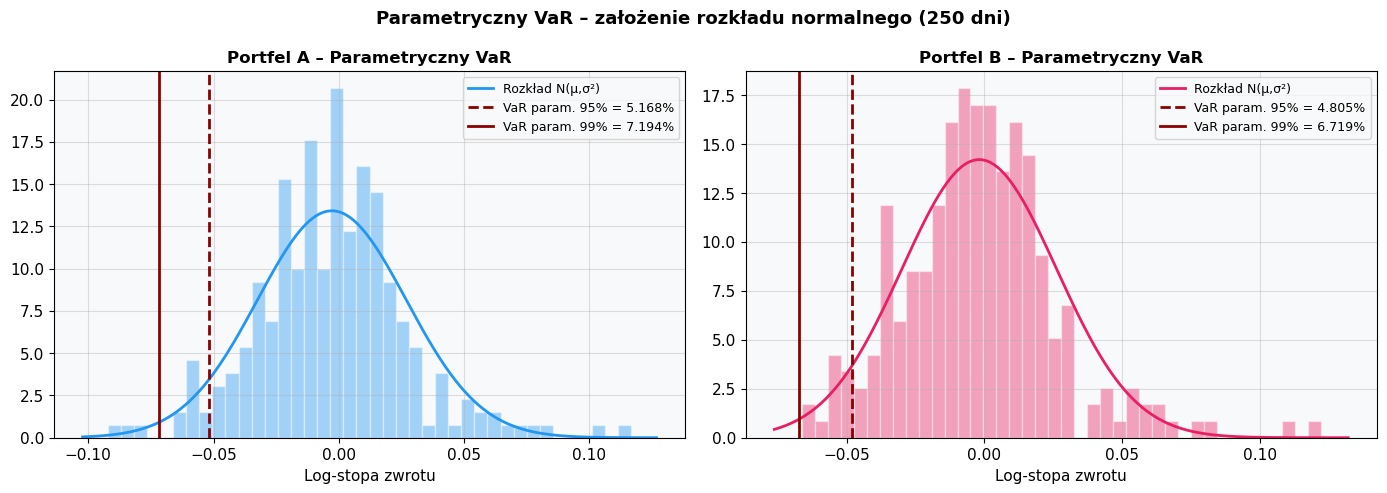

In [7]:
var_param = {}
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    var_param[label] = {}
    for cl in CONF_LEVELS:
        mu = ret.mean()
        sig = ret.std()
        z = stats.norm.ppf(1 - cl)
        var_param[label][cl] = -(mu + z * sig)

print('Parametryczny VaR (jako % wartości portfela):')
print(f'{"Portfel":<12}{"VaR 95%":>12}{"VaR 99%":>12}    μ dzienna     σ dzienna')
print('-' * 65)
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    print(f'Portfel {label:<5}{var_param[label][0.95]*100:>10.3f}%{var_param[label][0.99]*100:>12.3f}%  {ret.mean()*100:>8.4f}%  {ret.std()*100:>10.4f}%')

# Wizualizacja – gęstość normalna z zaznaczonymi VaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['A', 'B'],
                                  ['#2196F3', '#E91E63']):
    mu, sig = ret.mean(), ret.std()
    x = np.linspace(ret.min() - 0.01, ret.max() + 0.01, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sig), color=color, lw=2, label='Rozkład N(μ,σ²)')
    ax.hist(ret, bins=40, density=True, color=color, alpha=0.4, edgecolor='white')
    for cl, ls, lbl in [(0.95, '--', '95%'), (0.99, '-', '99%')]:
        v = var_param[label][cl]
        ax.axvline(-v, color='darkred', linestyle=ls, linewidth=2,
                   label=f'VaR param. {lbl} = {v*100:.3f}%')
    ax.set_title(f'Portfel {label} – Parametryczny VaR', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Parametryczny VaR – założenie rozkładu normalnego (250 dni)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('var_parametryczny.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Porównanie wyników

In [8]:
rows = []
for label in ['A', 'B']:
    for cl in CONF_LEVELS:
        vh = var_hist[label][cl]
        vp = var_param[label][cl]
        rows.append({
            'Portfel': f'Portfel {label}',
            'Poziom ufnosci': f'{int(cl*100)}%',
            'VaR historyczny': f'{vh*100:.4f}%',
            'VaR parametryczny': f'{vp*100:.4f}%',
            'Roznica (param - hist)': f'{(vp - vh)*100:+.4f}%'
        })

comparison = pd.DataFrame(rows)
print('Porownanie VaR – metoda historyczna vs. parametryczna\n')
display(comparison.set_index(['Portfel', 'Poziom ufnosci']))

Porownanie VaR – metoda historyczna vs. parametryczna



VaR historyczny VaR parametryczny  \
Portfel   Poziom ufnosci                                     
Portfel A 95%                    5.0587%           5.1680%   
          99%                    7.0917%           7.1936%   
Portfel B 95%                    4.6317%           4.8051%   
          99%                    5.5900%           6.7188%   

                         Roznica (param - hist)  
Portfel   Poziom ufnosci                         
Portfel A 95%                          +0.1093%  
          99%                          +0.1019%  
Portfel B 95%                          +0.1733%  
          99%                          +1.1288%

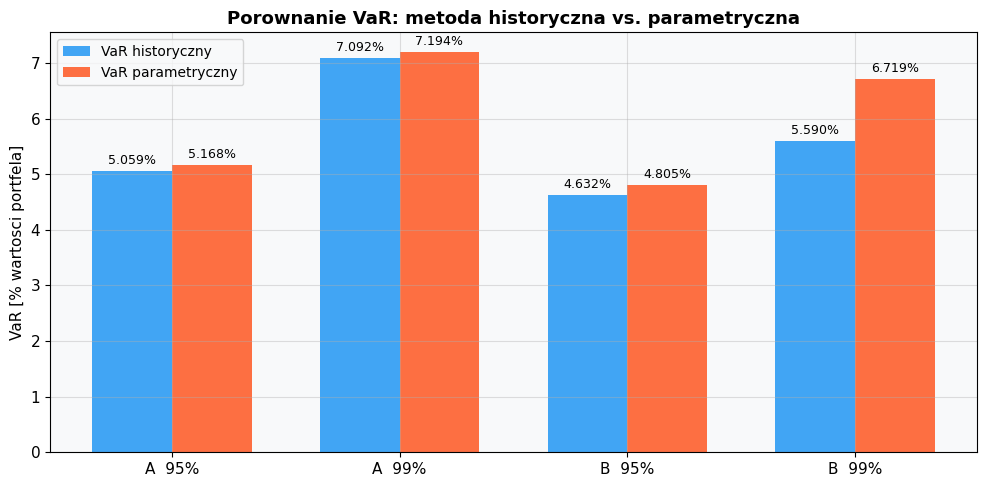

In [9]:
labels_plot = ['A  95%', 'A  99%', 'B  95%', 'B  99%']
vals_hist  = [var_hist['A'][0.95]*100,  var_hist['A'][0.99]*100,
              var_hist['B'][0.95]*100,  var_hist['B'][0.99]*100]
vals_param = [var_param['A'][0.95]*100, var_param['A'][0.99]*100,
              var_param['B'][0.95]*100, var_param['B'][0.99]*100]

x = np.arange(len(labels_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, vals_hist,  w, label='VaR historyczny',
            color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, vals_param, w, label='VaR parametryczny',
            color='#FF5722', alpha=0.85)
ax.bar_label(b1, fmt='%.3f%%', fontsize=9, padding=3)
ax.bar_label(b2, fmt='%.3f%%', fontsize=9, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylabel('VaR [% wartosci portfela]')
ax.set_title('Porownanie VaR: metoda historyczna vs. parametryczna',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('var_porownanie.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
print('Statystyki portfeli (okno 250 dni):')
print(f'{"Miara":<35}{"Portfel A":>15}{"Portfel B":>15}')
print('-' * 65)
miary = [
    ('Srednia dzienna',
     f'{ret_A_250.mean()*100:.4f}%', f'{ret_B_250.mean()*100:.4f}%'),
    ('Odch. std. dzienna',
     f'{ret_A_250.std()*100:.4f}%',  f'{ret_B_250.std()*100:.4f}%'),
    ('Skosnosc',
     f'{ret_A_250.skew():.4f}',      f'{ret_B_250.skew():.4f}'),
    ('Kurtoza (excess)',
     f'{ret_A_250.kurtosis():.4f}',  f'{ret_B_250.kurtosis():.4f}'),
    ('Min (najgorszy dzien)',
     f'{ret_A_250.min()*100:.4f}%',  f'{ret_B_250.min()*100:.4f}%'),
    ('VaR hist. 95%',
     f'{var_hist["A"][0.95]*100:.4f}%', f'{var_hist["B"][0.95]*100:.4f}%'),
    ('VaR hist. 99%',
     f'{var_hist["A"][0.99]*100:.4f}%', f'{var_hist["B"][0.99]*100:.4f}%'),
    ('VaR param. 95%',
     f'{var_param["A"][0.95]*100:.4f}%', f'{var_param["B"][0.95]*100:.4f}%'),
    ('VaR param. 99%',
     f'{var_param["A"][0.99]*100:.4f}%', f'{var_param["B"][0.99]*100:.4f}%'),
]
for nazwa, va, vb in miary:
    print(f'{nazwa:<35}{va:>15}{vb:>15}')

Statystyki portfeli (okno 250 dni):
Miara                                    Portfel A      Portfel B
-----------------------------------------------------------------
Srednia dzienna                           -0.2792%       -0.1860%
Odch. std. dzienna                         2.9722%        2.8082%
Skosnosc                                    0.4046         0.7545
Kurtoza (excess)                            1.7468         2.1484
Min (najgorszy dzien)                     -9.2255%       -6.6217%
VaR hist. 95%                              5.0587%        4.6317%
VaR hist. 99%                              7.0917%        5.5900%
VaR param. 95%                             5.1680%        4.8051%
VaR param. 99%                             7.1936%        6.7188%


## 8. Wnioski

### 8.1 Który portfel jest mniej ryzykowny?

**Portfel B (losowe wagi) jest mniej ryzykowny** według obu metod i obu poziomów ufności.

Wylosowane wagi Portfela B koncentrują się na GS (30,89%) i MS (32,94%) – bankach inwestycyjnych, które w oknie sierpień 2007 – lipiec 2008 radziły sobie relatywnie lepiej – przy jednoczesnej niskiej ekspozycji na AIG (6,67%) i C (8,73%), spółek z największymi stratami w tym okresie. Potwierdzają to zarówno niższy VaR historyczny (4,63% vs 5,06% przy 95%; 5,59% vs 7,09% przy 99%), jak i łagodniejszy najgorszy dzień: −6,62% (B) vs −9,23% (A).

Portfel B ma też niższe odchylenie standardowe (2,81% vs 2,97%), co bezpośrednio przekłada się na niższy VaR parametryczny.

> Różnice są **wyraźniejsze przy 99%** (ok. 1,5 pp przy VaR historycznym), co wskazuje, że przewaga Portfela B ujawnia się przede wszystkim w skrajnych scenariuszach strat.

---

### 8.2 Która metoda daje wyższy VaR?

**We wszystkich czterech przypadkach VaR parametryczny jest wyższy** niż historyczny, jednak skala różnic jest bardzo niejednorodna:

| Portfel | Poziom ufności | VaR historyczny | VaR parametryczny | Różnica |
|---------|---------------|----------------|------------------|---------|
| Portfel A | 95% | 5,0588% | 5,1680% | +0,1093% |
| Portfel A | 99% | 7,0917% | 7,1936% | +0,1019% |
| Portfel B | 95% | 4,6317% | 4,8051% | +0,1733% |
| Portfel B | 99% | 5,5900% | 6,7188% | +1,1288% |

Dla **Portfela A** różnica jest mała i zbliżona na obu poziomach ufności (~0,10 pp). Wynika to z umiarkowanej skośności (0,40) i niskiej kurtozy nadmiarowej (1,75) – rozkład jest stosunkowo bliski normalnemu, przez co metody dają podobne wyniki.

Dla **Portfela B** różnica jest mała przy 95% (+0,17 pp), ale gwałtownie rośnie przy 99% (+1,13 pp). Wyższa skośność (0,75) i kurtoza (2,15) oznaczają, że przy zagłębieniu się w dalszy ogon (kwantyl $z_{0.01} \approx 2{,}326$) gaussowski model coraz bardziej przeszacowuje prawdopodobieństwo dużych strat względem empirycznego rozkładu.

Przyczyną jest **dodatnia skośność** obu portfeli – gwałtowne odbicia rynkowe (marzec 2008 po Bear Stearns, lipiec 2008) tworzą długi prawy ogon empirycznego rozkładu, przez co lewy ogon empiryczny jest krótszy niż lewy ogon gaussowski. Model normalny zakłada symetrię i w efekcie przeszacowuje prawdopodobieństwo dużych strat.

---

### 8.3 Wniosek końcowy

W analizowanym oknie kryzysowym **metoda historyczna jest bardziej adekwatna** – bezpośrednio oddaje rzeczywisty kształt rozkładu, w tym jego dodatnią skośność, bez narzucania założenia symetrii.

Należy jednak podkreślić, że zależność ta nie jest uniwersalna: przy silnej ujemnej skośności lub wysokiej kurtozie nadmiarowej to metoda historyczna mogłaby niedoszacowywać ryzyko ogonowe. Dlatego **obie metody powinny być stosowane równolegle** jako wzajemny sprawdzian.